# 

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
from math import sqrt
from tqdm import tqdm
import pickle
from matplotlib import pyplot as plt

In [3]:
pools = pd.read_csv(
    '../data/pools/pools.csv',
    index_col=0,
    names=["index", "address", "version", "token0", "token1", "fee", "block_number", "timestamp", "tickspacing"]
).sort_index().drop_duplicates()
tokens = pd.read_csv(
    '../data/tokens/tokens.csv',
    index_col=0,
    names=["index", "address", "name", "symbol", "decimals"]
).sort_index().drop_duplicates()
print(len(pools))
print(len(tokens))

430384
406659


In [4]:
pools.head()

,address,version,token0,token1,fee,block_number,timestamp,tickspacing
index,,,,,,,,
1,0x00001bea43608c5ee487f82b773af8bd7cb20a6f,2,0x12898dabdbedd0fdc5c9ea4448d532ab55d92740,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,3000,17589578,1688097587,0
2,0x000024feb293b6c6c3a80a95f1f830a8746400b9,3,0x6aa56e1d98b3805921c170eb4b3fe7d4fda6d89b,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,10000,20425838,1722420503,200
3,0x00004ee988665cdda9a1080d5792cecd16dc1220,2,0x4d44d6c288b7f32ff676a4b2dafd625992f8ffbd,0xdac17f958d2ee523a2206206994597c13d831ec7,3000,11666388,1610801924,0
4,0x0000871c95bb027c90089f4926fd1ba82cdd9a8b,2,0x5152e1cb69a2ffa3997e89cbb4aba76a01d82141,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,3000,10986295,1601773155,0
5,0x000089906c37426585e860d02c545ab1d184a6ba,2,0x722383e1e8994cb8a55cbc1621dc068b62403b1e,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,3000,19685531,1713481823,0


In [5]:
tokens.head()

,address,name,symbol,decimals
index,,,,
0,0x12898dabdbedd0fdc5c9ea4448d532ab55d92740,Kabosu 2.0,KABOSU2.0,9
1,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,Wrapped Ether,WETH,18
2,0x6aa56e1d98b3805921c170eb4b3fe7d4fda6d89b,MAGA,TRUMP,9
3,0x4d44d6c288b7f32ff676a4b2dafd625992f8ffbd,Solution Life Coin,SLC,18
4,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USD,USDT,6


In [6]:
old_pools = pools[pools['block_number'] <= 18e6]
all_pools = old_pools[['token0', 'token1']].to_numpy().tolist()
G = nx.from_edgelist(all_pools, create_using=nx.MultiDiGraph)
print("all_pools: ", len(all_pools))
print("tokens: ", len(tokens))
print("nodes: ", len(G.nodes))
print("edges: ", len(G.edges))

remove = [node for (node, d) in dict(G.degree()).items() if d <= 4]
G.remove_nodes_from(remove)
print("after nodes: ", len(G.nodes))
print("after edges: ", len(G.edges))

all_pools:  257348
tokens:  406659
nodes:  241892
edges:  257348
after nodes:  1204
after edges:  7889


In [7]:
# filter based on degree
edges = list(G.edges())
mask = []
for (t0, t1) in tqdm(all_pools):
    if (t0, t1) in edges or (t1, t0) in edges:
        mask.append(True)
    else:
        mask.append(False)
masked_pools= old_pools[mask]
#masked_pools.to_csv('../data/pools/pools_deg_filter.csv', sep=',', header=False)

100%|█████████████████████████████████| 257348/257348 [00:44<00:00, 5802.59it/s]


In [8]:
filtered_tokens = list(G.nodes())
mask = []
for t in tokens['address']:
    if t in filtered_tokens:
        mask.append(True)
    else:
        mask.append(False)
masked_tokens = tokens[mask]
#masked_tokens.to_csv('../data/tokens_deg_filter_all.csv', sep=',', header=False)

In [9]:
prices = pd.read_parquet('../data/prices/prices.parquet').drop_duplicates()
prices.reset_index()
prices.head()

,pool_address,block_number,reserve_t0,reserve_t1,sqrt_price_x96
0,0x0002e63328169d7feea121f1e32e4f620abf0352,21810878,591379112586406197411,7514697609889,24980640316888636113055116
1,0x0004cd8474e882278e32e584699090be496f410e,21810878,1789432435576660297853997,21899650982,8635683066121563865695
2,0x0005ee2ef3f313ae168451ef8174b4fcc508819f,21810878,110542,10,None
3,0x000ba527862e5b82cff0f7c66b646af023274aa1,21810878,1243565337392500971972213,57124474485134695238,1166871022256290171535964128
4,0x000e0bbcfdba9490ee20b0a7900a4dff46317998,21810878,160820868314075,1213616988401802,29831852388212861267170748790


In [36]:
#weth_filter = 100e18
#iter_pools = masked_pools[masked_pools['address'].isin(list(prices['pool_address']))]
#mask = []
#for _, pool in tqdm(iter_pools.iterrows()):
#    try:
#        t0_a = pool['token0']
#        t1_a = pool['token1']
#        pool_price = prices[prices['pool_address'] == pool.address].iloc[0]
#        if t0_a == weth:
#            t0_w_r = int(pool_price['reserve_t0'])
#            mask.append(t0_w_r >= weth_filter)
#            continue
#        elif t1_a == weth:
#            t1_w_r = int(pool_price['reserve_t1'])
#            mask.append(t1_w_r >= weth_filter)
#            continue
#        else:
#            append = False
#            for i, token in enumerate([t0_a, t1_a]):
#                try:
#                    weth_pools = masked_pools[
#                        ((masked_pools['token0'] == token) | (masked_pools['token1'] == token))
#                        &
#                        ((masked_pools['token0'] == weth) | (masked_pools['token1'] == weth))
#                    ]
#                    price_entries = prices[prices['pool_address'].isin(weth_pools['address'])]
#                    if weth == weth_pools['token1'].iloc[0]:
#                        weth_list = list(int(a) for a in price_entries['reserve_t1'])
#                        max_entry = price_entries.iloc[weth_list.index(max(weth_list))]
#                        reserve_in_weth = cal_reserve(
#                            i,
#                            pool_price, 
#                            int(max_entry['reserve_t1']), 
#                            int(max_entry['reserve_t0'])
#                        )
#                        
#                    else:
#                        weth_list = list(int(a) for a in price_entries['reserve_t0'])
#                        max_entry = price_entries.iloc[weth_list.index(max(weth_list))]
#                        reserve_in_weth = cal_reserve(
#                            i,
#                            pool_price, 
#                            int(max_entry['reserve_t1']), 
#                            int(max_entry['reserve_t0'])
#                        )
#                    append = reserve_in_weth >= weth_filter and reserve_in_weth <= 1e25
#                except Exception as e:
#                    if len(weth_pools) > 1:
#                        print(f"len pools {len(weth_pools)}")
#                        print(f"token {token} , {i}")
#                        print(f"exception {e}, pool {pool['address']}")
#                        print(f"inner excetion {e}")
#                        print(f"append {append}")
#                        print("-------")
#                    continue
#                    
#        mask.append(append)
#    except Exception as e:
#        print(f"len pools {len(weth_pools)}")
#        print(f"exception {e}, pool {pool['address']}")
#        mask.append(False)
#def cal_reserve(i, pool_price, up, down):
#    if i == 0:
#        reserve_in_weth = (int(pool_price['reserve_t0'])*up)/down
#    else: 
#        reserve_in_weth = (int(pool_price['reserve_t1'])*up)/down
#    return reserve_in_weth
        
    

In [13]:
weth = "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2"
final = masked_pools
print("Tokens: ", len(set(list(final['token0']) + list(final['token1']))))
print("Pools: ", len(final))
print("Non weth pools: ", len(final[(final['token0'] != weth) & (final['token1'] != weth)]))

Tokens:  1197
Pools:  7889
Non weth pools:  5414


In [74]:
def make_price(price):
    block_price = []
    for _, p in price.iterrows():
        if (spx96 := p['sqrt_price_x96']) != None:
            block_price.append((int(spx96) / 2**96)**2)
        else:
            t0 = int(p['reserve_t0'])
            t1 = int(p['reserve_t1'])
            if t0 == 0:
                price = 0
            else:
                price = t1/t0
            block_price.append(price)
    return block_price

def filter_pools_with_no_gradient(pools, prices):
    pools = pools[pools['address'].isin(set(prices['pool_address']))]
    ticks = len(prices['block_number'].unique())
    mask = []
    for _, pool in pools.iterrows():
        t0 = pool['token0']
        t1 = pool['token1']
        p = make_price(prices[prices['pool_address'] == pool['address']])
        mask.append(np.count_nonzero(np.gradient(p)) > ticks//2 )

    pools = pools[mask]
    prices = prices[prices['pool_address'].isin(list(pools['address']))]
    return pools, prices

prices_seq = pd.read_parquet('../data/prices/prices_deg_5_liq_100_block_18.parquet')
grad_filter_pools, grad_filter_prices = filter_pools_with_no_gradient(final, prices_seq)
grad_filter_pools.to_csv('../data/pools/pools_deg_5_liq_100_block_18_grad.csv')

In [42]:
#final.to_csv('../data/pools/pools_deg_20_liq_100_block_20.csv', sep=',', header=False)

In [64]:
class MDP:
    def __init__(self, G):
        self.G = G
    
    def check_win(self, state):
        return state[0][1] == state[-1][1] and len(state) > 1
    
    def get_valid_actions(self, state):
        current_node = state[-1][1]
        filter_edges = [e for e in state[1:]] +\
            [(e[1], e[0], e[2]) for e in state[1:]]
    
        valid_actions = [e for e in self.G.edges(current_node, data='k') if e not in filter_edges]
        return valid_actions


def brute_force_search_trail(mdp, source, cutoff):
    def dfs(state):
        if len(trails) > 2:
            return
        if len(state) > cutoff:
            return

        if mdp.check_win(state):
            trails.append(state)
            return

        valid_actions = mdp.get_valid_actions(state)
        for action in valid_actions:
            dfs(state + [action])
        return

    trails = []
    state = [(source, source, 0)]
    dfs(state)
    return trails

In [68]:
def pools_to_edge_list(pools):
    edge_list = []
    cache = []
    for (_, pool) in pools.iterrows():
        t0 = pool['token0']
        t1 = pool['token1']
        k = 0
        for e in cache:
            if (t0, t1) == e or (t1, t0) == e:
                k += 1
        edge_list.append(
            (t0, t1,
             {'k': k, 'address': pool['address'], 'fee': int(pool['fee'])/1e6})
        )
        cache.append((t0, t1))

    return edge_list


edge_list = pools_to_edge_list(grad_filter_pools)
G = nx.MultiDiGraph()
G.add_edges_from(edge_list)

#mapping = {}
#for i, node in enumerate(list(G.nodes())):
#    mapping[node] = i
#G = nx.relabel_nodes(G, mapping)

edges = list(G.edges(data=True))
for (t0, t1, d) in edges:
    G.add_edge(t1, t0, k=d['k'], address=d['address'])

In [69]:
mdp = MDP(G)

In [70]:
l = []
for s in G.nodes():
    state = [(s, s, 0)]
    t = brute_force_search_trail(mdp, s, 7)
    print(s, len(t))
    if len(t) <= 2:
        l.append(s)


0xf21661d0d1d76d3ecb8e1b9f1c923dbfffae4097 0
0xf9a2d7e60a3297e513317ad1d7ce101cc4c6c8f6 0
0x2260fac5e5542a773aa44fbcfedf7c193bc2c599 3
0xd075e95423c5c4ba1e122cae0f4cdfa19b82881b 0
0x744d70fdbe2ba4cf95131626614a1763df805b9e 0
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 3
0x6b175474e89094c44da98b954eedeac495271d0f 3
0xfca59cd816ab1ead66534d82bc21e7515ce441cf 0
0x72e4f9f808c49a2a61de9c5896298920dc4eeea9 0
0x0100546f2cd4c9d97f798ffc9755e47865ff7ee6 0
0xbc6da0fe9ad5f3b0d58160288917aa56653660e9 0
0xdac17f958d2ee523a2206206994597c13d831ec7 3
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 3
0xde30da39c46104798bb5aa3fe8b9e0e1f348163f 0
0x5026f006b85729a8b14553fae6af249ad16c9aab 0
0x7f39c581f595b53c5cb19bd0b3f8da6c935e2ca0 3
0x6982508145454ce325ddbe47a25d4ec3d2311933 3
0xd31a59c85ae9d8edefec411d448f90841571b89c 0
0x111111517e4929d3dcbdfa7cce55d30d4b6bc4d6 0
0xb23d80f5fefcddaa212212f028021b41ded428cf 3
0x853d955acef822db058eb8505911ed77f175b99e 3
0xae78736cd615f374d3085123a210448e74fc6393 3
0x4da27a54

KeyboardInterrupt: 

In [ ]:
G.remove_nodes_from(l)
t = list(G.nodes())
ulti = final[final['token0'].isin(t) & final['token1'].isin(t)]
#ulti.to_csv('../data/pools/pools_deg_5_liq_100_block_18_paths_2.csv', sep=',', header=False)

In [29]:
p = pd.read_parquet('../data/prices/prices_deg_5_liq_100_block_18.parquet')

In [31]:
include = [int(np.random.choice(list((set(p['block_number']))))) for _ in range(6)]

In [34]:
a = p[p['block_number'].isin(include)]

In [36]:
a.to_parquet('../data/prices/prices_deg_5_liq_100_block_18_small.parquet')

In [37]:
include

[19548000, 19476000, 21096000, 18828000, 18108000]

In [22]:
paths = [
    "/home/miksa/values.pickle",
    "/home/miksa/values/values_1.pickle"
]
l = []
for path in paths:
    with open(path, 'rb') as f:
        l += pickle.load(f)
val, stat = zip(*l)
x = np.linspace(0, len(l), len(l))

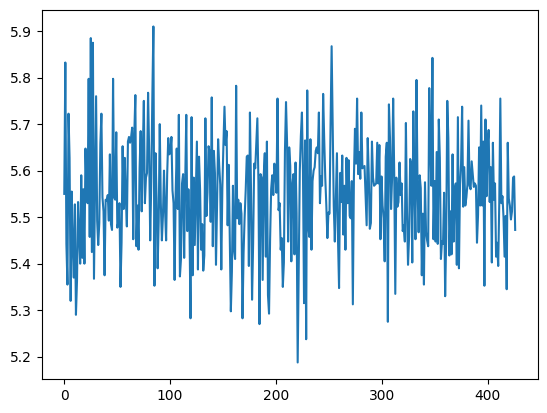

In [23]:
plt.plot(x, stat)

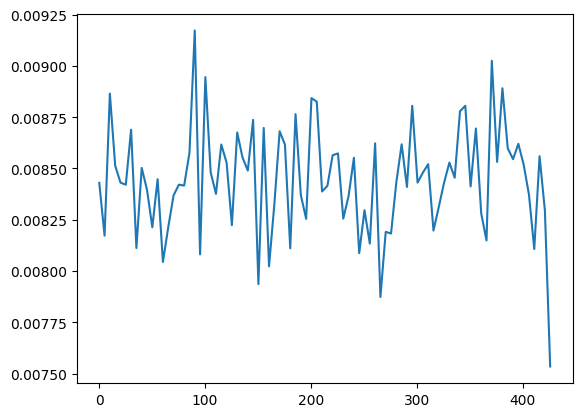

In [34]:
v = [np.mean(val[i:i+5]) for i in range(0, len(val), 5)]
x = np.linspace(0, len(val), len(v))
plt.plot(x, v)

In [32]:
with open('../rl_arb/train.picle', 'rb') as f:
    out = pickle.load(f)
profits, maximals, values = np.array(out)

In [33]:
np.mean(1 - (maximals/profits))

np.float64(-0.009464252289608085)

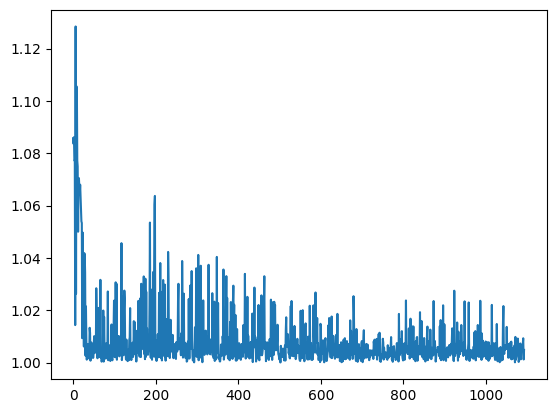